# Reinforcement Learning for Trade Execution

**Docker image**: `ml4t`

Static schedules (TWAP, VWAP) commit to a trading path before the session
reveals whether liquidity will be cheap or expensive. This notebook frames
execution as a **sequential control problem** and learns an adaptive policy
with tabular Q-learning, following Nevmyvaka, Feng, and Kearns (2006). The
agent decides, interval by interval, how aggressively to trade given the
remaining inventory, the time left in the session, and the most recently
completed interval's liquidity regime.

The score captures the trade-off emphasized by Almgren and Chriss: minimize
**execution cost** (half-spread plus market impact) **plus an exposure penalty**
for carrying inventory through volatile intervals. The exposure term used here
is a linear, bps-denominated teaching proxy, not the quadratic variance term in
the Almgren-Chriss mean-variance objective. Trading fast pays impact; trading
slow accepts exposure. An adaptive policy can lean either way using liquidity
and volatility already observed - a static schedule cannot.

Everything runs on **real AlgoSeek NASDAQ-100 minute bars**: real interval
volumes, real volume-weighted prices, real quoted spreads, and real intra-interval
volatility. The square-root impact term uses a fixed scenario coefficient (see
`03_market_impact_calibration`) applied to those real volumes; it is not presented
as an estimate fitted by this notebook.

**Learning Objectives**
- Cast trade execution as a finite-horizon Markov decision process
- Build a liquidity-only state (no directional/price features) so the policy
  solves execution, not alpha timing
- Train a tabular Q-learning policy on real sessions and evaluate it on
  held-out sessions against TWAP and VWAP
- Read the learned policy to see how it conditions on spread, volatility, and time

**Book Reference:** Chapter 18, Section 18.5 (Execution Algorithms as Controls)

**Prerequisites:** Read [`04_vwap_twap_execution`](04_vwap_twap_execution.ipynb) for the static baselines,
[`05_almgren_chriss_optimal_execution`](05_almgren_chriss_optimal_execution.ipynb) for the cost-risk objective,
and [`07_ml4t_volume_participation`](07_ml4t_volume_participation.ipynb) for participation mechanics on real liquidity.

## 1. Setup and Imports

In [1]:
"""Reinforcement Learning for Trade Execution - tabular Q-learning on real NASDAQ-100 liquidity."""

import warnings
from collections import defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from plotly.subplots import make_subplots

import utils  # noqa: F401
from data import load_nasdaq100_bars
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
# Real AlgoSeek NASDAQ-100 minute bars define the execution environment. The
# parent order is scheduled within a single session across a 15-minute grid;
# the policy is trained on the earlier sessions and evaluated on the later ones.
PRIMARY_SYMBOL = "AAPL"
TAQ_START_DATE = "2021-10-01"
TAQ_END_DATE = "2021-12-31"
INTERVAL_MINUTES = 15  # 09:30-16:00 → 26 intervals/session
ORDER_PCT_ADV = 0.10  # parent order target as a fraction of measured ADV
IMPACT_COEF_BPS = 10.0  # fixed square-root impact scenario coefficient
EXPOSURE_WEIGHT = 0.25  # bps penalty per unit normalized inventory-volatility exposure
MAX_PARTICIPATION = 0.25  # hard cap on realized interval participation
SHORTFALL_PENALTY_BPS = 100.0  # fixed terminal penalty for each unit of unfilled order fraction
TRAIN_FRACTION = 0.6  # earlier sessions train the policy; later sessions are held out
INV_BINS = 10  # inventory-remaining state bins
N_EPOCHS = 800  # Q-learning passes over the training sessions
ALPHA = 0.30  # learning rate
EPSILON_START = 0.5  # exploration rate (linearly decayed to 0)
SEED = 42

In [3]:
set_global_seeds(SEED)
# Actions are multipliers on the VWAP base slice (the volume-proportional rate).
# A multiplier of 1.0 reproduces VWAP exactly, so VWAP lies inside the policy
# class and the agent can only improve on it by conditioning on real-time state -
# the lagged-regime adaptation f(spread, volatility) discussed in Section 18.5.
ACTIONS = np.array([0.5, 0.75, 1.0, 1.3, 1.6])

## 2. Execution as a Sequential Control Problem

A desk must trade $Q$ shares before the close. At each of $H$ decision points
it chooses how much of the *remaining* inventory to release. The open uses a
training-only reference regime; later decisions observe only the most recently
completed interval - never the interval about to be traded. The episode is a
finite-horizon Markov decision process:

- **State** $s_t = (\text{time remaining}, \text{inventory remaining}, \text{spread}_{t-1}\text{ regime}, \text{volatility}_{t-1}\text{ regime})$
- **Action** $a_t \in \{0.5,\ 0.75,\ 1.0,\ 1.3,\ 1.6\}$ - a multiplier on the VWAP base slice ($1.0$ = trade exactly the VWAP rate this interval)
- **Reward** $r_t = -\big[\,c_t\,(q_t/Q) + \lambda\,(\bar I_t/Q)\,\sigma_t\,\big]$ - negative execution cost on the fill plus a linear exposure penalty on average inventory $\bar I_t$ carried while the interval unfolds
- **Liquidity rule** - realized fills cannot exceed 25% of interval volume
- **Terminal rule** - unfilled inventory after the close pays an explicit shortfall penalty

The score combines two quantities every execution desk trades off: market
impact (rises when you trade fast) and inventory exposure (rises when you trade
slow and carry inventory through volatile intervals). It is inspired by the
Almgren-Chriss cost-risk trade-off but does not claim to reproduce that model's
quadratic variance objective. A terminal shortfall term prevents the score from
treating infeasible close fills as completed trades.

Crucially, the state contains **no price or return feature**. This keeps the
problem a pure execution problem: the policy can only learn to route trades
toward cheap-liquidity, low-risk intervals, not to time directional drift. That
is the discipline the earlier gradient-boosting version of this notebook lacked.

Nevmyvaka, Feng, and Kearns (2006) introduced exactly this reinforcement-learning
formulation and showed that conditioning on real-time market state can improve on
static VWAP-style schedules.

## 3. Real Intraday Microstructure

We load AlgoSeek NASDAQ-100 minute bars and aggregate them onto a 15-minute
regular-session grid. Each interval carries its real traded volume, its
volume-weighted trade price, its volume-weighted relative quoted spread, and its
intra-interval realized volatility (the standard deviation of minute returns).

In [4]:
def load_intraday_panel(
    symbol: str,
    start_date: str,
    end_date: str,
    interval_minutes: int,
) -> pl.DataFrame:
    """Aggregate real minute bars onto an intraday execution grid.

    Returns per (date, bucket): interval volume, volume-weighted trade price,
    volume-weighted relative quoted spread (bps), and intra-interval realized
    volatility (bps), restricted to 09:30-16:00.
    """
    session_start = 9 * 60 + 30
    session_end = 16 * 60
    return (
        load_nasdaq100_bars(
            start_date=start_date,
            end_date=end_date,
            include_microstructure=True,
            lazy=True,
        )
        .filter(pl.col("symbol") == symbol)
        .select("timestamp", "volume", "last_trade_price", "close_bid_price", "close_ask_price")
        .filter(
            pl.col("last_trade_price").is_not_null()
            & (pl.col("volume") > 0)
            & (pl.col("close_bid_price") > 0)
            & (pl.col("close_ask_price") >= pl.col("close_bid_price"))
        )
        .with_columns(
            date=pl.col("timestamp").dt.date(),
            minute_of_day=pl.col("timestamp").dt.hour().cast(pl.Int32) * 60
            + pl.col("timestamp").dt.minute().cast(pl.Int32),
            rel_spread_bps=(
                (pl.col("close_ask_price") - pl.col("close_bid_price"))
                / ((pl.col("close_ask_price") + pl.col("close_bid_price")) / 2)
                * 1e4
            ),
        )
        .filter(
            (pl.col("minute_of_day") >= session_start) & (pl.col("minute_of_day") < session_end)
        )
        .with_columns(
            bucket=((pl.col("minute_of_day") - session_start) // interval_minutes).cast(pl.Int32)
        )
        .sort("date", "bucket", "timestamp")
        .group_by("date", "bucket")
        .agg(
            volume=pl.col("volume").sum(),
            price=(pl.col("last_trade_price") * pl.col("volume")).sum() / pl.col("volume").sum(),
            spread_bps=(pl.col("rel_spread_bps") * pl.col("volume")).sum() / pl.col("volume").sum(),
            vol_bps=(pl.col("last_trade_price").pct_change().std() * 1e4),
        )
        .sort("date", "bucket")
        .collect()
    )

In [5]:
N_BUCKETS = (16 * 60 - (9 * 60 + 30)) // INTERVAL_MINUTES
panel = load_intraday_panel(PRIMARY_SYMBOL, TAQ_START_DATE, TAQ_END_DATE, INTERVAL_MINUTES)
print(
    f"{PRIMARY_SYMBOL}: {panel.height:,} interval rows across "
    f"{panel['date'].n_unique()} sessions ({N_BUCKETS} intervals/session)"
)

AAPL: 1,664 interval rows across 64 sessions (26 intervals/session)


### Assemble Per-Session Arrays

Keep only sessions with full interval coverage so each session yields aligned
price, volume, spread, and volatility arrays of length `N_BUCKETS`.

In [6]:
def session_arrays(panel: pl.DataFrame, n_buckets: int) -> dict:
    """Return {date: {price, volume, spread_bps, vol_bps}} for fully covered sessions."""
    out = {}
    for d in panel["date"].unique().to_list():
        g = panel.filter(pl.col("date") == d).sort("bucket")
        if g.height == n_buckets and g["vol_bps"].null_count() == 0:
            out[d] = {
                "price": g["price"].to_numpy(),
                "volume": g["volume"].to_numpy(),
                "spread_bps": g["spread_bps"].to_numpy(),
                "vol_bps": g["vol_bps"].to_numpy(),
            }
    return out

In [7]:
sessions = session_arrays(panel, N_BUCKETS)
all_days = sorted(sessions)
split_idx = int(len(all_days) * TRAIN_FRACTION)
train_days = all_days[:split_idx]
test_days = all_days[split_idx:]

# ADV measured on training sessions only so the parent order size that drives
# every strategy's evaluation does not see held-out volume.
train_day_set = set(train_days)
adv = float(
    panel.filter(pl.col("date").is_in(list(train_day_set)))
    .group_by("date")
    .agg(dv=pl.col("volume").sum())["dv"]
    .mean()
)
order_shares = int(round(ORDER_PCT_ADV * adv))
print(f"Full-coverage sessions: {len(all_days)} ({len(train_days)} train, {len(test_days)} test)")
print(f"Measured ADV: {adv:,.0f} shares")
print(f"Parent order target: {order_shares:,} shares ({ORDER_PCT_ADV:.0%} of ADV)")

Full-coverage sessions: 64 (38 train, 26 test)
Measured ADV: 32,556,430 shares
Parent order target: 3,255,643 shares (10% of ADV)


**Finding**: The parent order is a tenth of a training-window day's volume
scheduled inside a single session, so under a flat trajectory it targets roughly 10% of average
interval volume. Realized fills remain subject to the 25% participation cap.

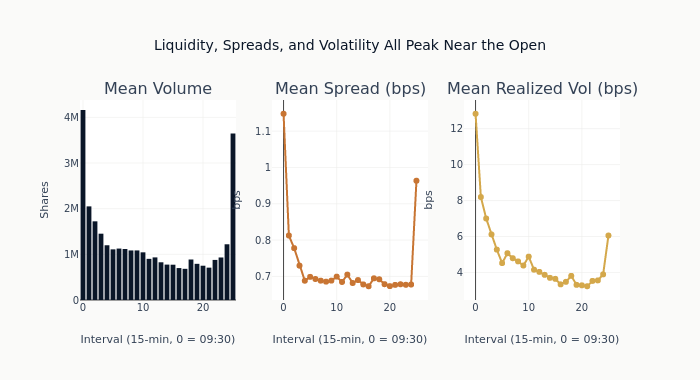

In [8]:
# Visualize the real microstructure regimes the policy will condition on.
mean_volume = np.vstack([sessions[d]["volume"] for d in train_days]).mean(axis=0)
mean_spread = np.vstack([sessions[d]["spread_bps"] for d in train_days]).mean(axis=0)
mean_vol = np.vstack([sessions[d]["vol_bps"] for d in train_days]).mean(axis=0)
bucket_idx = np.arange(N_BUCKETS)

# VWAP base slice (shares per interval) from the training volume profile. The RL
# action scales this slice up or down; a multiplier of 1.0 everywhere is VWAP.
volume_profile = mean_volume / mean_volume.sum()
base_slice = order_shares * volume_profile

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=[
        "Mean Volume",
        "Mean Spread (bps)",
        "Mean Realized Vol (bps)",
    ],
)
fig.add_bar(x=bucket_idx, y=mean_volume, marker_color=COLORS["blue"], row=1, col=1)
fig.add_scatter(
    x=bucket_idx,
    y=mean_spread,
    mode="lines+markers",
    line_color=COLORS["copper"],
    row=1,
    col=2,
)
fig.add_scatter(
    x=bucket_idx,
    y=mean_vol,
    mode="lines+markers",
    line_color=COLORS["amber"],
    row=1,
    col=3,
)
fig.update_xaxes(title_text=f"Interval ({INTERVAL_MINUTES}-min, 0 = 09:30)")
fig.update_yaxes(title_text="Shares", row=1, col=1)
fig.update_yaxes(title_text="bps", row=1, col=2)
fig.update_yaxes(title_text="bps", row=1, col=3)
fig.update_layout(
    title="Liquidity, Spreads, and Volatility All Peak Near the Open",
    height=380,
    showlegend=False,
)
fig.show()

**Finding**: The three regimes pull in different directions. Volume is U-shaped
(heavy at the open and close), the relative spread is widest at the open, and
realized volatility is also highest at the open. So the open offers the deepest
liquidity (low impact) but the widest spread *and* the most volatility - trading
there is cheap on impact yet exposes the fill to wide spreads, while *waiting*
leaves inventory exposed to open volatility. The policy cannot know the open's
completed regime in advance; it may react to that observation only from the
following interval.

## 4. An Execution-Plus-Exposure Score on Real Data

Every fill pays half the quoted spread plus square-root market impact against
the interval's **real** volume:

$$c_t = \tfrac{1}{2}\,\text{spread}_t + \kappa\sqrt{\frac{q_t}{V_t}}\ \text{(bps)}$$

Carrying inventory is also costly. Because fills are released through interval
$t$, average inventory $\bar I_t$ between the pre-fill and post-fill levels is
exposed to that interval's realized volatility $\sigma_t$. The linear exposure
proxy contributes $\lambda\,(\bar I_t/Q)\,\sigma_t$. Any residual inventory
$I_H$ after the final capped fill pays a fixed shortfall penalty $\eta I_H/Q$.
The total teaching score is

$$\text{Score} = \underbrace{\sum_t c_t\,\frac{q_t}{Q}}_{\text{execution cost}}
\;+\; \underbrace{\lambda\sum_t \frac{\bar I_t}{Q}\,\sigma_t}_{\text{exposure proxy}}
\;+\; \underbrace{\eta\frac{I_H}{Q}}_{\text{terminal shortfall}}\quad\text{(bps)}.$$

This bps-denominated proxy is deliberately interpretable, but it is not the
quadratic inventory-variance term of the Almgren-Chriss mean-variance model.

In [9]:
def interval_cost_bps(spread_bps: float, volume: float, shares: float) -> float:
    """Execution cost (bps) for a fill: half-spread plus square-root impact."""
    participation = np.sqrt(max(shares, 0.0) / max(volume, 1.0))
    return spread_bps / 2.0 + IMPACT_COEF_BPS * participation


def capped_fill(requested: float, remaining: float, interval_volume: float) -> float:
    """Realize a nonnegative request subject to inventory and participation limits."""
    capacity = MAX_PARTICIPATION * max(interval_volume, 0.0)
    return float(min(max(requested, 0.0), remaining, capacity))


def schedule_components(shares: np.ndarray, sess: dict) -> tuple[float, float, float]:
    """Return execution, exposure, and terminal-shortfall costs in bps."""
    shares = shares.astype(float)
    if np.any(shares < 0) or np.any(np.cumsum(shares) > order_shares + 1e-8):
        raise ValueError("realized fills must be nonnegative and cannot exceed the parent order")
    exec_cost = 0.0
    exposure_cost = 0.0
    remaining = float(order_shares)
    for q, spread, volume_t, sig in zip(
        shares, sess["spread_bps"], sess["volume"], sess["vol_bps"]
    ):
        remaining_after = remaining - q
        average_inventory = 0.5 * (remaining + remaining_after)
        exposure_cost += EXPOSURE_WEIGHT * (average_inventory / order_shares) * sig
        if q > 0:
            exec_cost += interval_cost_bps(spread, volume_t, q) * (q / order_shares)
        remaining = remaining_after
    shortfall_cost = SHORTFALL_PENALTY_BPS * (remaining / order_shares)
    return exec_cost, exposure_cost, shortfall_cost


def schedule_score_bps(shares: np.ndarray, sess: dict) -> float:
    """Execution, exposure, and terminal-shortfall score in bps."""
    exec_cost, exposure_cost, shortfall_cost = schedule_components(shares, sess)
    return exec_cost + exposure_cost + shortfall_cost

## 5. State Discretization

The continuous state is mapped to a small grid so a tabular Q-table can cover
it. Spread and volatility regimes are binned against quantiles measured on the
**training** sessions only. The open uses training medians; interval `t > 0`
uses the completed aggregates from interval `t - 1`.

In [10]:
training_spreads = np.concatenate([sessions[d]["spread_bps"] for d in train_days])
training_volatility = np.concatenate([sessions[d]["vol_bps"] for d in train_days])
spread_terciles = np.quantile(training_spreads, [1 / 3, 2 / 3])
vol_median = float(np.median(training_volatility))
initial_spread_bps = float(np.median(training_spreads))
initial_vol_bps = vol_median


def observable_regime(sess: dict, t: int) -> tuple[float, float]:
    """Regime known before interval ``t`` starts, with a training-only open prior."""
    if t == 0:
        return initial_spread_bps, initial_vol_bps
    return float(sess["spread_bps"][t - 1]), float(sess["vol_bps"][t - 1])


def encode_state(t: int, remaining: float, spread_bps: float, vol_bps: float) -> tuple:
    """Map (time, inventory, spread, volatility) to a discrete Q-table key."""
    inv_frac = min(remaining / order_shares, 0.999) if order_shares > 0 else 0.0
    inv_bin = int(inv_frac * INV_BINS)
    spread_bin = int(np.digitize(spread_bps, spread_terciles))  # 0,1,2
    vol_bin = int(vol_bps >= vol_median)  # 0 calm, 1 volatile
    return (t, inv_bin, spread_bin, vol_bin)

## 6. Tabular Q-Learning

We run finite-horizon Q-learning (no discounting) over the training sessions.
Before each interval the agent picks an action $\epsilon$-greedily - a multiplier
on the VWAP base slice - using only completed-interval information. It releases
that request through the real interval, observes the realized cost and exposure,
and
updates $Q(s,a) \leftarrow Q(s,a) + \alpha\,[\,r + \max_{a'} Q(s',a') - Q(s,a)\,]$.
Each request is metered as volume arrives and cannot exceed 25% of realized
interval volume. The final interval requests any residual, but the same cap
applies; remaining inventory pays the explicit terminal shortfall penalty.

In [11]:
def run_episode(sess: dict, q_table: dict, epsilon: float, learn: bool) -> tuple[np.ndarray, float]:
    """Roll one session forward under the policy; optionally apply Q-updates.

    Returns the realized per-interval fills and execution score (bps). With
    ``learn=False`` and ``epsilon=0`` this is the greedy
    evaluation of the current policy.
    """
    remaining = float(order_shares)
    shares = np.zeros(N_BUCKETS)

    for t in range(N_BUCKETS):
        observed_spread, observed_vol = observable_regime(sess, t)
        state = encode_state(t, remaining, observed_spread, observed_vol)
        if t == N_BUCKETS - 1:
            action_idx = len(ACTIONS) - 1  # request the residual subject to the same cap
        elif learn and np.random.random() < epsilon:
            action_idx = np.random.randint(len(ACTIONS))
        else:
            action_idx = int(np.argmax(q_table[state]))

        multiplier = ACTIONS[action_idx]
        requested = (
            remaining
            if t == N_BUCKETS - 1
            else float(min(remaining, round(multiplier * base_slice[t])))
        )
        qty = capped_fill(requested, remaining, sess["volume"][t])
        shares[t] = qty

        # The request fills through interval t. Average pre/post inventory is
        # exposed while the interval unfolds; realized interval inputs enter only
        # the reward observed after the action.
        remaining_after = remaining - qty
        average_inventory = 0.5 * (remaining + remaining_after)
        exposure_cost = EXPOSURE_WEIGHT * (average_inventory / order_shares) * sess["vol_bps"][t]
        exec_cost = (
            interval_cost_bps(sess["spread_bps"][t], sess["volume"][t], qty) * (qty / order_shares)
            if qty > 0
            else 0.0
        )
        shortfall_cost = (
            SHORTFALL_PENALTY_BPS * (remaining_after / order_shares) if t == N_BUCKETS - 1 else 0.0
        )
        reward = -(exec_cost + exposure_cost + shortfall_cost)

        remaining = remaining_after

        if learn:
            if t < N_BUCKETS - 1:
                next_state = encode_state(
                    t + 1, remaining, sess["spread_bps"][t], sess["vol_bps"][t]
                )
                if t + 1 == N_BUCKETS - 1:
                    # Terminal next state - the residual request uses the final
                    # action slot, so bootstrap from that action's value rather
                    # than the max over phantom unvisited actions (which would
                    # zero out the terminal shortfall cost in the value
                    # function).
                    target = reward + q_table[next_state][len(ACTIONS) - 1]
                else:
                    target = reward + np.max(q_table[next_state])
            else:
                target = reward
            q_table[state][action_idx] += ALPHA * (target - q_table[state][action_idx])

    return shares, schedule_score_bps(shares, sess)

### Train the Policy

In [12]:
def train_q_policy(train_days: list, sessions: dict) -> dict:
    """Q-learning over training sessions with linearly decayed exploration."""
    q_table = defaultdict(lambda: np.zeros(len(ACTIONS)))
    order = list(train_days)
    for epoch in range(N_EPOCHS):
        epsilon = EPSILON_START * (1 - epoch / N_EPOCHS)
        np.random.shuffle(order)
        for d in order:
            run_episode(sessions[d], q_table, epsilon, learn=True)
    return q_table

In [13]:
print("Training Q-learning execution policy...")
q_table = train_q_policy(train_days, sessions)
print(f"Policy trained: {len(q_table):,} visited states over {N_EPOCHS} epochs")

Training Q-learning execution policy...


Policy trained: 765 visited states over 800 epochs


**Finding**: The Q-table covers a few hundred discrete states - small enough to
read directly in Section 9, which is the point of a tabular policy: the learned
rule is fully inspectable rather than hidden in a function approximator.

## 7. Static Baselines

TWAP trades an equal share of the order each interval. VWAP allocates shares in
proportion to the **training-window** volume profile, so its forecast is strictly
out-of-sample on the test sessions.

In [14]:
def shares_from_weights(weights: np.ndarray, total: int) -> np.ndarray:
    """Allocate integer shares across intervals in proportion to weights."""
    raw = total * (weights / weights.sum())
    shares = np.floor(raw).astype(int)
    remainder = total - int(shares.sum())
    if remainder > 0:
        top = np.argsort(raw - shares)[-remainder:]
        shares[top] += 1
    return shares


twap_shares = shares_from_weights(np.ones(N_BUCKETS), order_shares)
vwap_shares = shares_from_weights(mean_volume, order_shares)

A static schedule defines a target cumulative trajectory. If the 25% cap prevents
a target fill, the missed quantity carries forward. The close requests all remaining
inventory, but the cap still applies and any residual becomes explicit shortfall.

In [15]:


def execute_static_schedule(target_shares: np.ndarray, sess: dict) -> np.ndarray:
    """Follow a target trajectory while carrying capped fills forward."""
    if not np.isclose(target_shares.sum(), order_shares):
        raise ValueError("target schedule must conserve the parent order")
    fills = np.zeros(N_BUCKETS)
    cumulative_target = 0.0
    filled = 0.0
    for t in range(N_BUCKETS):
        remaining = order_shares - filled
        cumulative_target += target_shares[t]
        requested = remaining if t == N_BUCKETS - 1 else max(cumulative_target - filled, 0.0)
        fills[t] = capped_fill(requested, remaining, sess["volume"][t])
        filled += fills[t]
    return fills

## 8. Evaluation on Held-Out Sessions

We run all three policies on the test sessions and compare the execution,
exposure, and shortfall score. The Q-policy acts greedily; the baselines apply
their fixed target trajectories. All three pass through the same 25% fill cap,
carry missed target quantity forward, and pay the same terminal shortfall
penalty. Differences therefore reflect when each policy requests liquidity.

In [16]:
def participation_diagnostics(shares: np.ndarray, sess: dict) -> tuple[float, float, float]:
    """Maximum participation, terminal participation, and terminal shares."""
    participation = np.divide(shares, sess["volume"])
    return float(participation.max()), float(participation[-1]), float(shares[-1])


def evaluate(test_days: list, sessions: dict, q_table: dict) -> pl.DataFrame:
    """Score components and participation per held-out session and policy."""
    rows = []
    for d in test_days:
        sess = sessions[d]
        rl_shares, _ = run_episode(sess, q_table, epsilon=0.0, learn=False)
        realized = {
            "RL": rl_shares,
            "TWAP": execute_static_schedule(twap_shares, sess),
            "VWAP": execute_static_schedule(vwap_shares, sess),
        }
        for name, sh in realized.items():
            exec_cost, exposure_cost, shortfall_cost = schedule_components(sh, sess)
            max_participation, terminal_participation, terminal_shares = participation_diagnostics(
                sh, sess
            )
            rows.append(
                {
                    "session": d,
                    "strategy": name,
                    "exec_cost_bps": exec_cost,
                    "exposure_cost_bps": exposure_cost,
                    "shortfall_cost_bps": shortfall_cost,
                    "score_bps": exec_cost + exposure_cost + shortfall_cost,
                    "max_participation": max_participation,
                    "terminal_participation": terminal_participation,
                    "terminal_shares": terminal_shares,
                    "shortfall_shares": order_shares - sh.sum(),
                    "shortfall_fraction": (order_shares - sh.sum()) / order_shares,
                }
            )
    return pl.DataFrame(rows)

In [17]:
eval_df = evaluate(test_days, sessions, q_table)

summary = (
    eval_df.group_by("strategy")
    .agg(
        mean_exec_cost=pl.col("exec_cost_bps").mean(),
        mean_exposure_cost=pl.col("exposure_cost_bps").mean(),
        mean_shortfall_cost=pl.col("shortfall_cost_bps").mean(),
        mean_score=pl.col("score_bps").mean(),
        median_score=pl.col("score_bps").median(),
        worst_participation=pl.col("max_participation").max(),
        worst_terminal_participation=pl.col("terminal_participation").max(),
        worst_shortfall_fraction=pl.col("shortfall_fraction").max(),
    )
    .sort("mean_score")
)
print(f"Held-out evaluation: {eval_df['session'].n_unique()} sessions ({PRIMARY_SYMBOL})")

Held-out evaluation: 26 sessions (AAPL)


In [18]:
paired_scores = eval_df.pivot(on="strategy", index="session", values="score_bps").sort("session")
n_test_sessions = paired_scores.height
rl_wins_vwap = paired_scores.filter(pl.col("RL") < pl.col("VWAP")).height
rl_wins_twap = paired_scores.filter(pl.col("RL") < pl.col("TWAP")).height
rl_minus_vwap = paired_scores["RL"] - paired_scores["VWAP"]
rl_minus_twap = paired_scores["RL"] - paired_scores["TWAP"]
summary_by_strategy = {row["strategy"]: row for row in summary.to_dicts()}

display(
    Markdown(
        f"**Held-out finding**: Mean execution, exposure, and shortfall score is "
        f"{summary_by_strategy['RL']['mean_score']:.2f} bps for RL, "
        f"{summary_by_strategy['VWAP']['mean_score']:.2f} for VWAP, and "
        f"{summary_by_strategy['TWAP']['mean_score']:.2f} for TWAP. "
        f"On paired sessions, RL is lower than VWAP in {rl_wins_vwap}/{n_test_sessions} "
        f"and lower than TWAP in {rl_wins_twap}/{n_test_sessions}. The median RL-minus-VWAP "
        f"difference is {rl_minus_vwap.median():+.2f} bps "
        f"(IQR {rl_minus_vwap.quantile(0.25):+.2f} to {rl_minus_vwap.quantile(0.75):+.2f}); "
        f"against TWAP it is {rl_minus_twap.median():+.2f} bps "
        f"(IQR {rl_minus_twap.quantile(0.25):+.2f} to {rl_minus_twap.quantile(0.75):+.2f}). "
        f"These summaries describe this historical holdout; they are not a deployment guarantee."
    )
)

**Held-out finding**: Mean execution, exposure, and shortfall score is 22.90 bps for RL, 28.14 for VWAP, and 31.28 for TWAP. On paired sessions, RL is lower than VWAP in 26/26 and lower than TWAP in 26/26. The median RL-minus-VWAP difference is -4.93 bps (IQR -6.72 to -3.27); against TWAP it is -7.38 bps (IQR -10.20 to -5.83). These summaries describe this historical holdout; they are not a deployment guarantee.

In [19]:
worst_participation = float(eval_df["max_participation"].max())
worst_terminal_participation = float(eval_df["terminal_participation"].max())
worst_shortfall_fraction = float(eval_df["shortfall_fraction"].max())
if worst_participation > MAX_PARTICIPATION + 1e-12:
    raise ValueError("a modeled fill exceeds the hard participation cap")
display(
    Markdown(
        f"**Terminal-liquidity audit**: The largest realized participation is "
        f"{worst_participation:.1%}, including {worst_terminal_participation:.1%} in the "
        f"final interval, so every fill respects the {MAX_PARTICIPATION:.0%} hard cap. "
        f"The largest unfilled close residual is {worst_shortfall_fraction:.1%} of the parent "
        f"order and is charged at {SHORTFALL_PENALTY_BPS:.0f} bps per unit shortfall fraction."
    )
)

**Terminal-liquidity audit**: The largest realized participation is 25.0%, including 25.0% in the final interval, so every fill respects the 25% hard cap. The largest unfilled close residual is 40.5% of the parent order and is charged at 100 bps per unit shortfall fraction.

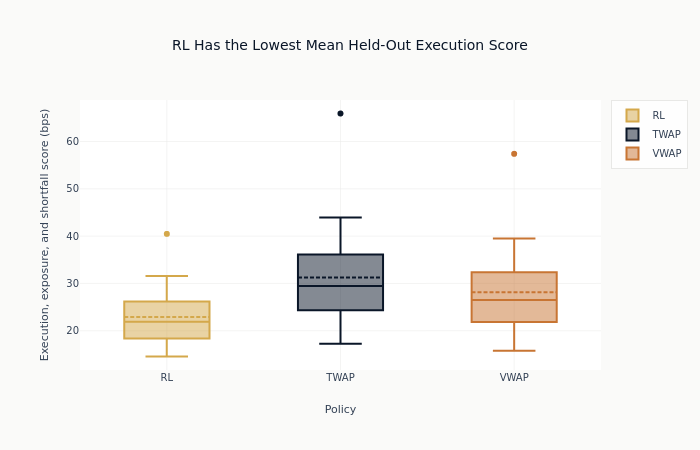

In [20]:
# Distribution of the total score by policy.
fig = go.Figure()
colors = {"RL": COLORS["amber"], "TWAP": COLORS["blue"], "VWAP": COLORS["copper"]}
for strat in ["RL", "TWAP", "VWAP"]:
    vals = eval_df.filter(pl.col("strategy") == strat)["score_bps"].to_list()
    fig.add_box(y=vals, name=strat, marker_color=colors[strat], boxmean=True)
fig.update_layout(
    title=f"{summary['strategy'][0]} Has the Lowest Mean Held-Out Execution Score",
    xaxis_title="Policy",
    yaxis_title="Execution, exposure, and shortfall score (bps)",
    height=450,
)
fig.show()

The marginal distributions show dispersion, while the paired counts above answer
the session-by-session question directly. The comparison remains a descriptive
result for this chronological holdout.

### Cost-vs-Exposure Decomposition

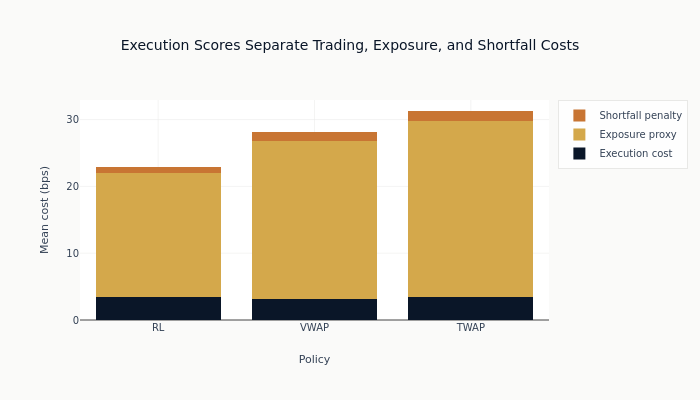

In [21]:
# Show how each policy splits the score between execution cost and exposure.
fig = go.Figure()
strategies = summary["strategy"].to_list()
exec_means = [eval_df.filter(pl.col("strategy") == s)["exec_cost_bps"].mean() for s in strategies]
exposure_means = [
    eval_df.filter(pl.col("strategy") == s)["exposure_cost_bps"].mean() for s in strategies
]
shortfall_means = [
    eval_df.filter(pl.col("strategy") == s)["shortfall_cost_bps"].mean() for s in strategies
]
fig.add_bar(x=strategies, y=exec_means, name="Execution cost", marker_color=COLORS["blue"])
fig.add_bar(x=strategies, y=exposure_means, name="Exposure proxy", marker_color=COLORS["amber"])
fig.add_bar(
    x=strategies, y=shortfall_means, name="Shortfall penalty", marker_color=COLORS["copper"]
)
fig.update_layout(
    title="Execution Scores Separate Trading, Exposure, and Shortfall Costs",
    xaxis_title="Policy",
    yaxis_title="Mean cost (bps)",
    barmode="stack",
    height=400,
)
fig.show()

In [22]:
display(
    Markdown(
        f"**Decomposition**: RL averages "
        f"{summary_by_strategy['RL']['mean_exec_cost']:.2f} bps of execution cost and "
        f"{summary_by_strategy['RL']['mean_exposure_cost']:.2f} bps of exposure, "
        f"plus {summary_by_strategy['RL']['mean_shortfall_cost']:.2f} bps of shortfall penalty. "
        f"VWAP averages {summary_by_strategy['VWAP']['mean_exec_cost']:.2f}, "
        f"{summary_by_strategy['VWAP']['mean_exposure_cost']:.2f}, and "
        f"{summary_by_strategy['VWAP']['mean_shortfall_cost']:.2f} bps, respectively."
    )
)

**Decomposition**: RL averages 3.45 bps of execution cost and 18.60 bps of exposure, plus 0.84 bps of shortfall penalty. VWAP averages 3.18, 23.61, and 1.34 bps, respectively.

## 9. Reading the Learned Policy

Because the Q-table is tabular, we can compare calm and volatile decisions while
holding time, inventory, and spread regime fixed. This matched-state diagnostic
avoids attributing a different time or inventory distribution to volatility. A
multiplier above 1.0 trades faster than the VWAP base slice; below 1.0 holds back.

In [23]:
def matched_volatility_policy(q_table: dict) -> pl.DataFrame:
    """Greedy calm/volatile actions for matched time, inventory, and spread states."""
    spread_labels = {0: "tight", 1: "medium", 2: "wide"}
    rows = []
    for (t, inv_bin, spread_bin, vol_bin), calm_q in q_table.items():
        volatile_key = (t, inv_bin, spread_bin, 1)
        if vol_bin != 0 or t == N_BUCKETS - 1 or volatile_key not in q_table:
            continue
        volatile_q = q_table[volatile_key]
        if not np.any(calm_q != 0) or not np.any(volatile_q != 0):
            continue
        calm_multiplier = float(ACTIONS[int(np.argmax(calm_q))])
        volatile_multiplier = float(ACTIONS[int(np.argmax(volatile_q))])
        rows.append(
            {
                "time": t,
                "inventory_bin": inv_bin,
                "spread_regime": spread_labels[spread_bin],
                "calm_multiplier": calm_multiplier,
                "volatile_multiplier": volatile_multiplier,
                "volatile_minus_calm": volatile_multiplier - calm_multiplier,
            }
        )
    if not rows:
        raise ValueError("no matched calm/volatile policy states were learned")
    return pl.DataFrame(rows)

In [24]:
matched_policy = matched_volatility_policy(q_table)
matched_policy_summary = (
    matched_policy.group_by("spread_regime")
    .agg(
        matched_states=pl.len(),
        calm_multiplier=pl.col("calm_multiplier").mean(),
        volatile_multiplier=pl.col("volatile_multiplier").mean(),
        volatile_minus_calm=pl.col("volatile_minus_calm").mean(),
        volatile_faster_share=(pl.col("volatile_minus_calm") > 0).mean(),
    )
    .sort("spread_regime")
)
matched_policy_summary.with_columns(pl.col(pl.Float64).round(3))

spread_regime,matched_states,calm_multiplier,volatile_multiplier,volatile_minus_calm,volatile_faster_share
str,u32,f64,f64,f64,f64
"""medium""",119,0.882,0.91,0.028,0.412
"""tight""",114,0.915,0.996,0.081,0.456
"""wide""",116,0.996,0.959,-0.037,0.345


In [25]:
matched_state_count = matched_policy.height
mean_matched_difference = float(matched_policy["volatile_minus_calm"].mean())
volatile_faster_count = matched_policy.filter(pl.col("volatile_minus_calm") > 0).height
display(
    Markdown(
        f"**Matched-state diagnostic**: Across {matched_state_count} learned state pairs that "
        f"hold time, inventory, and spread fixed, the volatile-state multiplier averages "
        f"{mean_matched_difference:+.3f} relative to the calm state and is higher in "
        f"{volatile_faster_count}/{matched_state_count} pairs. This measures the policy table's "
        f"lagged-volatility conditioning without conflating it with state composition."
    )
)

**Matched-state diagnostic**: Across 349 learned state pairs that hold time, inventory, and spread fixed, the volatile-state multiplier averages +0.024 relative to the calm state and is higher in 141/349 pairs. This measures the policy table's lagged-volatility conditioning without conflating it with state composition.

## 10. Summary

- **Execution is a control problem, not a prediction problem.** Casting it as a
  finite-horizon MDP makes the levers explicit: time remaining, inventory
  remaining, and the cost of trading now versus carrying inventory longer.
- **A liquidity-only state keeps the policy honest.** With no price or return
  feature, the agent cannot drift into directional timing - it can only learn to
  route trades using lagged liquidity and volatility regimes. This is the
  discipline the earlier gradient-boosting version of this notebook lacked.
- **The environment is entirely real.** Volume, price, spread, and volatility
  come from AlgoSeek minute bars; the square-root impact coefficient and linear
  exposure weight are explicit scenario parameters applied to those inputs.
  A hard participation cap prevents fictitious terminal liquidity; residual
  inventory is visible and penalized rather than silently force-filled.

**Next**: [`05_almgren_chriss_optimal_execution`](05_almgren_chriss_optimal_execution.ipynb)
derives the closed-form cost-variance optimal trajectory;
[`07_ml4t_volume_participation`](07_ml4t_volume_participation.ipynb) covers hard
liquidity constraints.

## Key Takeaways

1. **Execution as sequential control**: trading $Q$ shares before the close is a
   finite-horizon MDP whose state is time- and inventory-remaining plus the
   most recently completed liquidity regime. Tabular Q-learning solves it on a
   discretized grid and yields a fully inspectable policy.

2. **Liquidity-only state by design**: the state deliberately excludes price and
   return features, so the learned policy optimizes execution cost and inventory
   exposure rather than directional drift - the exact failure mode a feature-importance
   audit would otherwise have to police.

3. **Lagged conditioning is testable rather than asserted**: the matched-state
   table isolates how the learned action changes with the latest completed
   volatility regime, while paired held-out counts show how often the resulting
   policy has a lower score than each baseline. Both are descriptive results for
   this sample, not deployment guarantees.